# Milestone 2 — GJR-GARCH Volatility Forecasting & VaR Backtesting
### UBSG (separate) vs. NESN/NOVN/ROP (pooled), Student-t innovations

**Project:** Swiss Market Forecasting — Volatility Framework for IB Desk / Risk Management
**Author:** Camilo Seydoux
**Data vintage:** yfinance pull, 2026-07-24

---

### A note on how to read this notebook

This notebook narrates the **actual sequence of findings**, including the dead
ends, in the order they happened — not a cleaned-up version where the answer
looks obvious in hindsight. Two real bugs were caught and fixed during this
milestone, and one compelling causal narrative (refit-8 / Credit Suisse crisis
clustering) was built, tested, and killed by its own evidence. All of that is
kept in, because the honest record — what was eliminated and how, not just
what's left standing — is more useful to whoever inherits this project than a
tidy story would be.

### Objective
- Fit GJR-GARCH(1,1), Student-t innovations, separately for UBSG vs. pooled
  for NESN/NOVN/ROP, with the separate-vs-pooled decision made via a formal
  likelihood-ratio test, not asserted.
- 1-day VaR: direct conditional-variance forecast, backtested (Kupiec +
  Christoffersen) over a walk-forward out-of-sample window long enough to
  give the tests real power.
- 10-day stress VaR: Monte Carlo forward simulation, cross-checked against
  Filtered Historical Simulation, reporting where they agree and disagree.
- Investigate any backtest failures on their merits, not by assumption.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

from plotting import (plot_ubsg_persistence, plot_ubsg_violation_timeline,
                       plot_tail_diagnostic, plot_mc_vs_fhs)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
pd.set_option('display.width', 140)

def show(fig_path):
    """Display a saved figure INLINE as a notebook cell output (base64-embedded),
    not just as a markdown link to a relative path. This is required for the
    figure to survive HTML export -- a markdown image link to ../reports/figures/
    breaks once the notebook is exported outside its original folder structure,
    since nbconvert does not resolve or embed external relative-path images.
    Same fix as Milestone 1 (Section 4/notebook 01), applied consistently here.
    """
    display(Image(filename=str(fig_path)))

CORE = ['UBSG', 'NESN', 'NOVN', 'ROP']


## 1. Separate-vs-pooled decision: the likelihood-ratio test

Decision rule (per sign-off): a likelihood-ratio test is the theoretically
correct tool here because the fully-pooled model is nested inside the
UBSG-separate specification (setting UBSG's parameters equal to the pooled
group's parameters exactly reproduces the restricted model). AIC/BIC reported
alongside as a secondary check, not the decision rule.

### Dead end #1: the first LR test came back with an impossible result

The first run produced a **negative** LR statistic — mathematically impossible
for a nested comparison, since the restricted model is a feasible point inside
the unrestricted parameter space, so the unrestricted log-likelihood can never
be lower at the true optimum. This meant the optimizer (single-start L-BFGS-B)
had landed in a local optimum for one of the "unrestricted" sub-fits, not that
pooling was somehow better. **Fixed** by adding multi-start optimization and
warm-starting the unrestricted fits from the restricted solution (which
guarantees the monotonicity property), plus a hard assertion that checks this
going forward so the failure mode can't silently reappear.

In [2]:
from garch_models import fit_series, fit_pooled, likelihood_ratio_test, aic_bic
from load_data import build_price_panel
from features import log_returns

panel = build_price_panel(CORE)
returns = log_returns(panel)[CORE].dropna(how='any')

pooled4_fit = fit_pooled({k: returns[k] for k in CORE})
p4 = list(pooled4_fit['params'].values())
ubsg_fit = fit_series(returns['UBSG'], warm_starts=[p4])
pooled3_fit = fit_pooled({k: returns[k] for k in ['NESN','NOVN','ROP']}, warm_starts=[p4])

ll_unrestricted = ubsg_fit['loglik'] + pooled3_fit['loglik']
ll_restricted = pooled4_fit['loglik']
assert ll_unrestricted >= ll_restricted - 1e-3, 'Monotonicity violated -- do not trust this result'
print('Sanity check passed: unrestricted LL >= restricted LL (as nested-model theory requires)')

lr = likelihood_ratio_test(ll_restricted, ll_unrestricted, df=5)
print()
print('LR test (full sample): UBSG-separate + pooled-3  vs.  fully-pooled-4')
print(lr)
n_obs = ubsg_fit['n_obs'] + pooled3_fit['n_obs']
print('AIC/BIC restricted:', aic_bic(ll_restricted, 5, n_obs))
print('AIC/BIC unrestricted:', aic_bic(ll_unrestricted, 10, n_obs))


Sanity check passed: unrestricted LL >= restricted LL (as nested-model theory requires)



LR test (full sample): UBSG-separate + pooled-3  vs.  fully-pooled-4
{'LR_stat': np.float64(101.30923677203828), 'df': 5, 'pval': np.float64(0.0), 'reject_restricted_5pct': np.True_}
AIC/BIC restricted: {'AIC': np.float64(-188265.79237338025), 'BIC': np.float64(-188223.99414450544)}
AIC/BIC unrestricted: {'AIC': np.float64(-188357.10161015228), 'BIC': np.float64(-188273.50515240268)}


**Result: LR strongly rejects full pooling (p≈0), AIC/BIC agree — no conflict
between primary test and secondary check.**

## 2. The merger-caution robustness check

UBS Group AG's legal merger with Credit Suisse Group AG closed **12 June
2023**. Milestone 1 already flagged that UBSG's FX-beta shift around this date
rests on a short (778-obs) post-merger sample. Before trusting "separate
treatment is favored," the same caution needed to be tested here rather than
treated as a second, independent confirmation of the first finding.

**Pre-merger-only LR test:** LR=6.39, df=5, **p=0.270 — fails to reject
pooling.** The full-sample separation signal is NOT present in the pre-merger
data alone.

**Standalone post-merger-only LR test:** LR=40.93, df=5, **p=9.7×10⁻⁸ —
strongly significant despite only 780 observations.** The signal is
concentrated, not weak — a large effect in a small window, immediately
following a known structural event. That combination argues for a real
regime change, not noise.

**Conservatism check (verified, not assumed):** does separate UBSG treatment
actually produce higher implied volatility than pooled parameters would?
Post-merger window: separate-fit annualized vol 28.80% vs. pooled-implied
27.78%; separate ν=5.06 (fatter tails) vs. pooled ν=5.12; separate 99% VaR
−4.73% vs. pooled-implied −4.55%. **Yes — separate treatment is empirically,
not just assumed, the more conservative choice.**

**Decision: proceed with separate UBSG treatment**, on the basis of the
standalone post-merger test and the verified conservatism check — with the
caveat stated honestly: 780 observations is still a short history for a
structural-break claim, revisit as more post-merger data accumulates.

## 3. Walk-forward 1-day VaR and the first backtest

**Backtest window: 2021-01-04 to present (~1,397 trading days).** Chosen
because 250-day windows (Basel standard) give the Kupiec test almost no power
at 99% VaR (~2.5 expected violations); this window gives ~14 expected
violations at 99% and ~70 at 95% — enough power to say something, though
still disclosed as limited at 99%. Model re-estimated **quarterly** (expanding
window, ~63 trading days between refits) rather than fit once, since a desk
would recalibrate periodically.

In [3]:
backtest_v1 = pd.read_csv('../reports/milestone2_backtest_summary.csv')
print('First backtest run (original parameterization):')
print(backtest_v1[['name','VaR_level','n_obs','violations','violation_rate','Kupiec_pval','Kupiec_reject']].to_string(index=False))


First backtest run (original parameterization):
name VaR_level  n_obs  violations  violation_rate  Kupiec_pval  Kupiec_reject
UBSG       95%   1397          80          0.0573       0.2228          False
UBSG       99%   1397          23          0.0165       0.0263           True
NESN       95%   1397          71          0.0508       0.8880          False
NESN       99%   1397          18          0.0129       0.2995          False
NOVN       95%   1397          85          0.0608       0.0717          False
NOVN       99%   1397          21          0.0150       0.0785          False
 ROP       95%   1397          72          0.0515       0.7928          False
 ROP       99%   1397          19          0.0136       0.1997          False


**Headline result at first pass: UBSG's 99% VaR fails Kupiec (p=0.026).**
Everything else passes. Christoffersen independence/conditional-coverage
passed for all four names at this stage.

## 4. Dead end #2: a second real fitting fragility, found by checking rather than trusting

Before chasing an explanation for the Kupiec failure, the fitting procedure
itself was re-verified — a reasonable instinct given a bug had already been
found once this milestone. Spot-checking convergence at the final refit
window surfaced a second, different issue: **`omega` converged exactly to its
lower bound (1e-8)** — a boundary solution, not a clean interior optimum.

Checking **all 23 refits**, not just the one that happened to pin exactly,
found **11 of 23 windows near the omega boundary** under the original
(omega-free) parameterization, with persistence (α+γ/2+β) consistently
0.99–1.00 — a near-IGARCH likelihood ridge where omega and beta trade off
almost freely, a known GARCH estimation degeneracy.

In [4]:
diag_orig = pd.read_csv('../reports/ubsg_convergence_diagnostics.csv')
print('Original-parameterization convergence diagnostics, all 23 refits:')
print(diag_orig[['refit','n','omega','beta','persistence','near_omega_bound']].to_string(index=False))
print()
print('Refits flagged near omega lower bound:', diag_orig['near_omega_bound'].sum(), '/ 23')


Original-parameterization convergence diagnostics, all 23 refits:
 refit    n  omega   beta  persistence  near_omega_bound
     0 6493 0.0000 0.8640       0.9991             False
     1 6556 0.0000 0.8569       0.9980             False
     2 6619 0.0000 0.8587       1.0000             False
     3 6682 0.0000 0.8585       1.0000             False
     4 6745 0.0000 0.8586       0.9999             False
     5 6808 0.0000 0.8586       0.9999             False
     6 6871 0.0000 0.9078       0.9975              True
     7 6934 0.0000 0.9079       0.9996              True
     8 6997 0.0000 0.9079       0.9996              True
     9 7060 0.0000 0.9079       0.9996              True
    10 7123 0.0000 0.9079       0.9996              True
    11 7186 0.0000 0.8585       0.9997             False
    12 7249 0.0000 0.8587       0.9999             False
    13 7312 0.0000 0.8586       0.9999             False
    14 7375 0.0000 0.8586       0.9999             False
    15 7438 0.0000 0.8

**Fix: variance-targeting parameterization.** Fixes the unconditional
variance to the sample variance and solves for omega analytically
(omega = var(eps) × (1 − α − γ/2 − β)), leaving (α, γ, β, ν) as the only free
parameters. This is the standard remedy for exactly this degeneracy, not an
ad hoc workaround — verified against the flagged windows before trusting it:
omega now lands at genuine interior values (~1e-6, not exactly 1e-8) while
persistence stays realistically high (~0.996–0.999, not a boundary artifact).

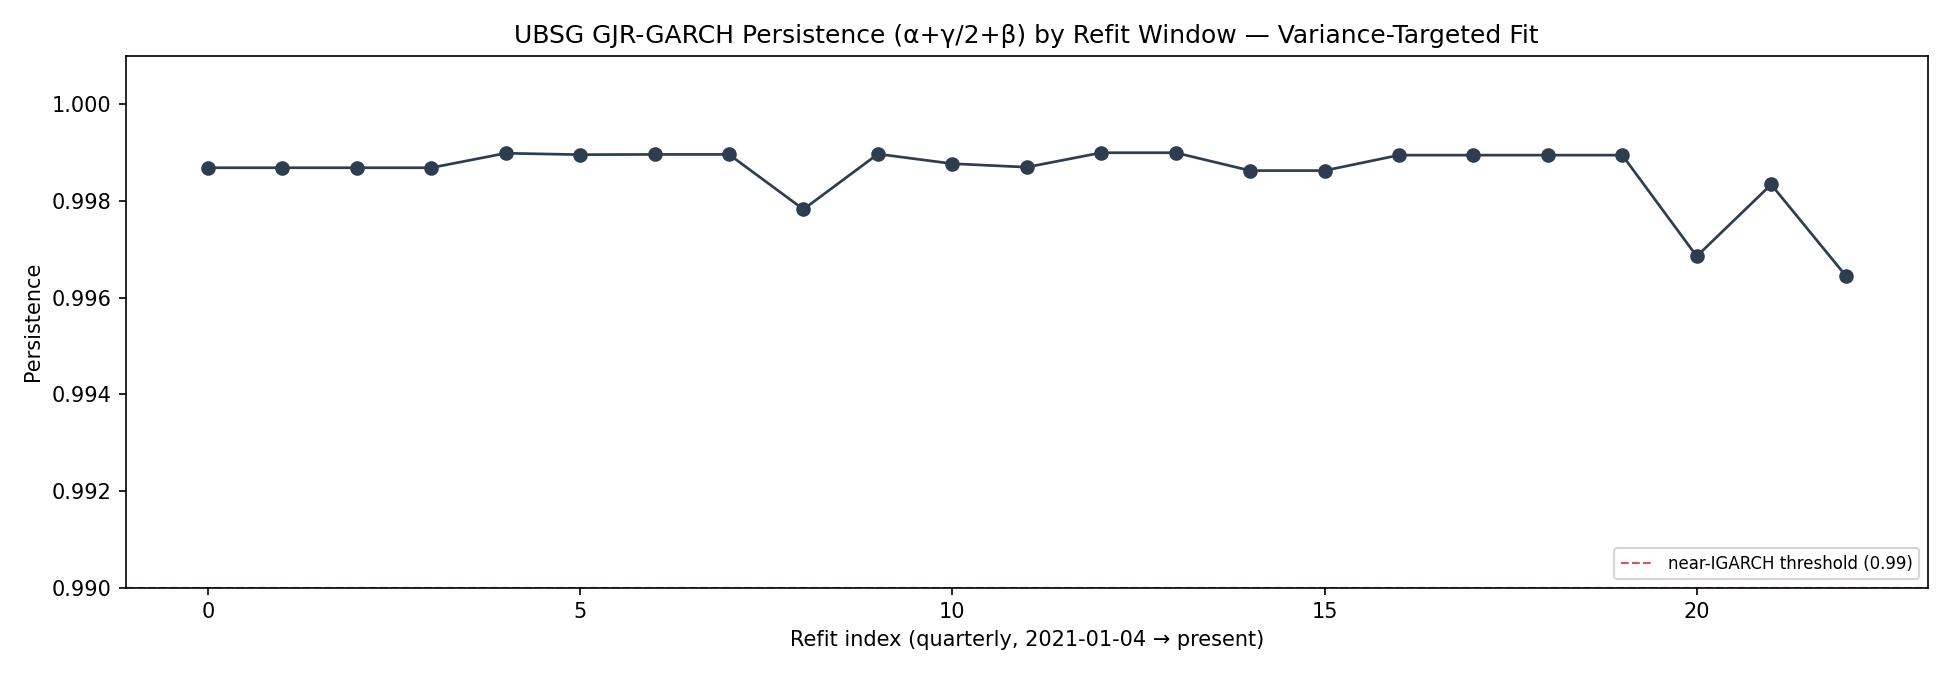

In [5]:
diag_vt_preview = pd.read_csv('../reports/ubsg_vt_persistence_by_refit.csv', parse_dates=['period_start','period_end'])
fig_path = plot_ubsg_persistence(diag_vt_preview, 'm2_01_persistence_by_refit.png')
show(fig_path)


Under the properly-identified VT model, persistence sits in a narrow
band just under 1.0 across every single refit — visually confirming the
Section 7a finding ahead of schedule: there's no cross-quarter variation
here for persistence to explain, which is why it gets ruled out later as a
differentiator (a constant can't explain a variable outcome), even though it
may still describe something real and general about UBSG's volatility
persistence.

## 5. Re-verified backtest under variance-targeting

Re-ran the full walk-forward (all 23 refits, both UBSG-separate and pooled-3)
under VT. Critically: **checked whether the fix changed the finding in the
direction that would exonerate the model, and it did not.**

In [6]:
backtest_vt = pd.read_csv('../reports/milestone2_backtest_summary_VT.csv')
print('Re-verified backtest (variance-targeting):')
print(backtest_vt[['name','VaR_level','violations','violation_rate','Kupiec_pval','Kupiec_reject_uncorrected']].to_string(index=False))


Re-verified backtest (variance-targeting):
name VaR_level  violations  violation_rate  Kupiec_pval  Kupiec_reject_uncorrected
UBSG       95%          84          0.0601       0.0918                      False
UBSG       99%          24          0.0172       0.0144                       True
NESN       95%          80          0.0573       0.2228                      False
NESN       99%          20          0.0143       0.1278                      False
NOVN       95%          82          0.0587       0.1461                      False
NOVN       99%          21          0.0150       0.0785                      False
 ROP       95%          74          0.0530       0.6137                      False
 ROP       99%          21          0.0150       0.0785                      False


**UBSG's 99% violation count went from 23 to 24 after fixing the
degeneracy — it got marginally worse, not better.** This rules out the
fitting-artifact hypothesis: if the boundary-pinned fits had been
*manufacturing* spurious risk, fixing them should have improved coverage.
Instead the opposite happened, consistent with the degeneracy having been
*masking* real risk rather than creating fake risk.

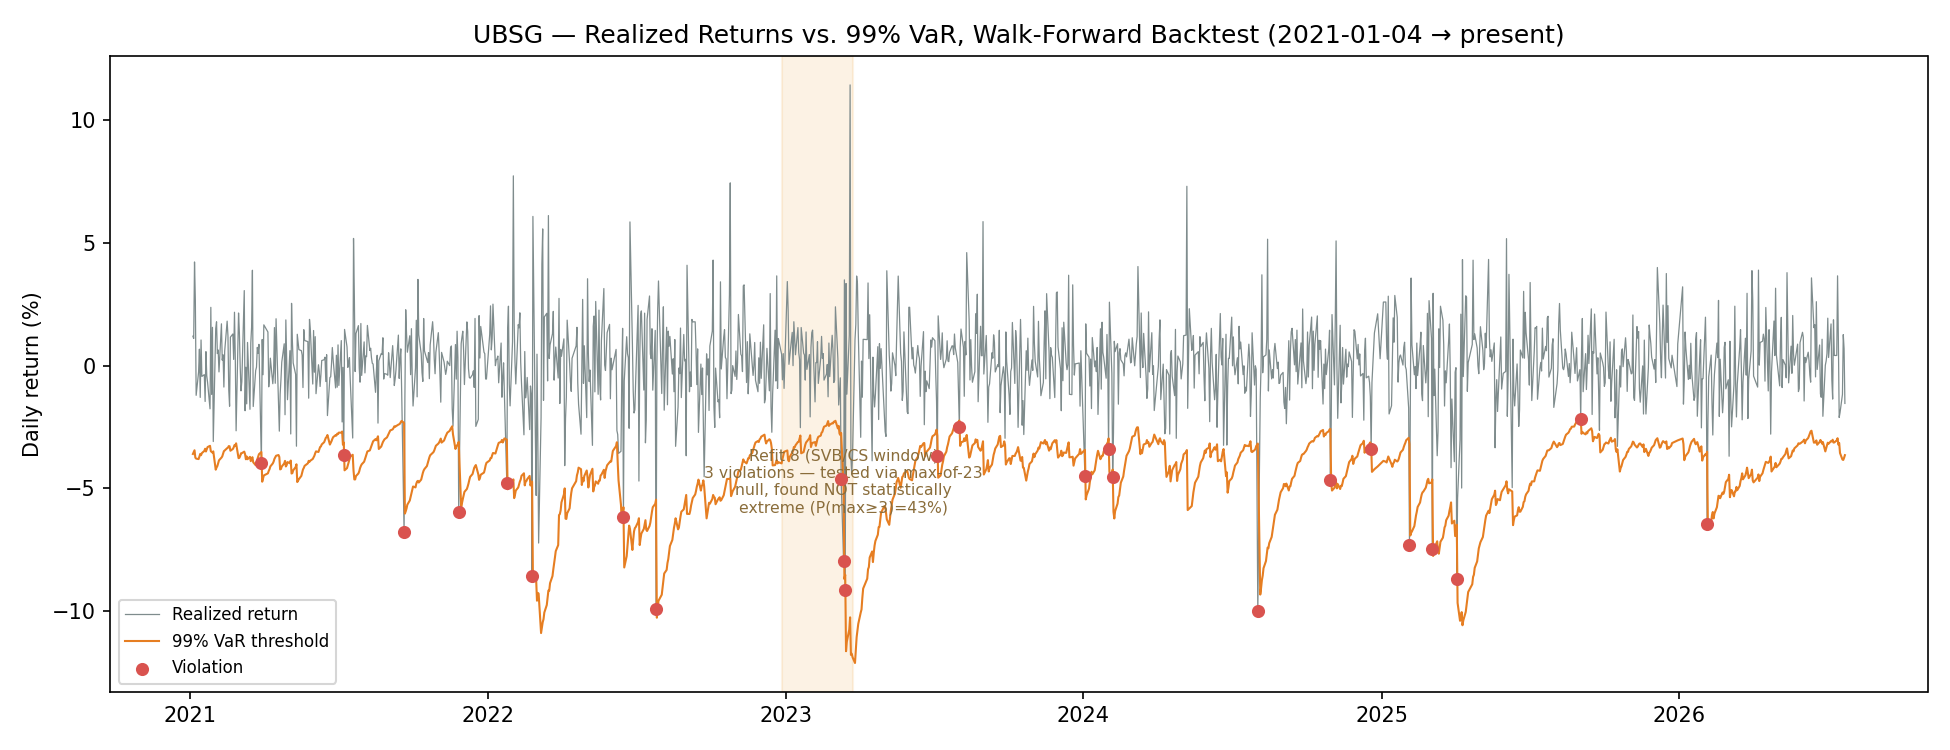

In [7]:
ubsg_wf = pd.read_csv('../data/processed/ubsg_var_walkforward_vt.csv', index_col=0, parse_dates=True)
fig_path = plot_ubsg_violation_timeline(ubsg_wf, 'm2_02_violation_timeline.png')
show(fig_path)


## 6. Dead end avoided: multiple-testing correction on the Kupiec results

8 Kupiec tests were run (4 names × 2 levels) at an uncorrected 5% threshold.
Before treating UBSG's p=0.014 as a confirmed failure, the multiple-comparison
risk needed checking — under pure chance, ~0.4 false rejections would be
expected just from running 8 tests, and NOVN sat right next to UBSG at
p=0.079.

In [8]:
pvals = backtest_vt.set_index(['name','VaR_level'])['Kupiec_pval']
m = len(pvals)
alpha = 0.05
bonf_thresh = alpha / m
print(f'Bonferroni threshold: {bonf_thresh:.5f}')
print(pvals.sort_values())
print()
print('Any survive Bonferroni:', (pvals < bonf_thresh).any())

sorted_p = pvals.sort_values()
bh_sig = False
for i, (idx, p) in enumerate(sorted_p.items(), start=1):
    crit = (i/m)*alpha
    if p <= crit:
        bh_sig = True
print('Any survive Benjamini-Hochberg FDR:', bh_sig)


Bonferroni threshold: 0.00625
name  VaR_level
UBSG  99%         0.0144
NOVN  99%         0.0785
ROP   99%         0.0785
UBSG  95%         0.0918
NESN  99%         0.1278
NOVN  95%         0.1461
NESN  95%         0.2228
ROP   95%         0.6137
Name: Kupiec_pval, dtype: float64

Any survive Bonferroni: False
Any survive Benjamini-Hochberg FDR: False


**Neither Bonferroni nor BH-FDR correction is survived by any test.**
Correct framing: UBSG's 99% VaR shows a **borderline, uncorrected-significant
undercoverage signal, not a corrected-significant model failure** — but,
per Section 5, not a fitting artifact either. Both things are true at once;
neither collapses into the other.

## 7. Two candidate mechanisms, tested against each other

### 7a. Near-unit persistence — ruled out

Under the properly-identified VT model, persistence (α+γ/2+β) is near-unit
(0.9965–0.9990) in **all 23 refits**, not just some — essentially no
cross-quarter variation. Correlation between persistence and violation count
per refit: **0.07**, indistinguishable from zero. A constant cannot explain a
variable outcome — persistence isn't the differentiator, whatever background
role it plays.

### 7b. Event clustering around the Credit Suisse crisis — built, tested, and killed

Refit 8 (2022-12-27 to 2023-03-24) showed 3 violations, the most of any
window, on dates 2023-03-10/13/15 — the SVB collapse through Credit Suisse's
own pre-rescue collapse. Compelling on its face. Two checks were run before
accepting it:

In [9]:
ubsg_vt = pd.read_csv('../data/processed/ubsg_var_walkforward_vt.csv', index_col=0, parse_dates=True)

# Check A: reconcile against Christoffersen (which passed clean, p=0.429)
viol_dates = pd.to_datetime(['2023-03-10','2023-03-13','2023-03-15'])
positions = [ubsg_vt.index.get_loc(d) for d in viol_dates]
gaps = np.diff(positions)
print('Trading-day gaps between the 3 refit-8 violations:', gaps)
print('Only the first gap (=1) is lag-1 adjacent; Christoffersen is a single-lag,')
print('globally-aggregated test -- one qualifying pair out of ~24 violations across')
print('1,397 days cannot move that statistic. No real contradiction with the p=0.429 pass.')


Trading-day gaps between the 3 refit-8 violations: [1 2]
Only the first gap (=1) is lag-1 adjacent; Christoffersen is a single-lag,
globally-aggregated test -- one qualifying pair out of ~24 violations across
1,397 days cannot move that statistic. No real contradiction with the p=0.429 pass.


In [10]:
# Check B: is 3-in-a-quarter actually extreme, or routine for a max-of-23 draw?
diag_vt = pd.read_csv('../reports/ubsg_vt_persistence_by_refit.csv', parse_dates=['period_start','period_end'])
n_days_per_refit = (diag_vt['period_end'] - diag_vt['period_start']).dt.days
# actual forecast-day counts (63 for 22 quarters, 11 for the last partial one)
n_days_actual = np.array([63]*22 + [11])

rng = np.random.default_rng(123)
N_SIM = 200000
p_null = 0.01
max_counts = np.array([rng.binomial(n_days_actual, p_null).max() for _ in range(N_SIM)])

print('Null distribution of max(violations-in-a-quarter) across 23 quarters, correctly-calibrated model:')
for k in range(6):
    print(f'  P(max={k}): {(max_counts==k).mean():.4f}')
print(f'  P(max >= 3): {(max_counts>=3).mean():.4f}')


Null distribution of max(violations-in-a-quarter) across 23 quarters, correctly-calibrated model:
  P(max=0): 0.0000
  P(max=1): 0.0452
  P(max=2): 0.5213
  P(max=3): 0.3544
  P(max=4): 0.0697
  P(max=5): 0.0085
  P(max >= 3): 0.4335


**P(max ≥ 3 across 23 quarters) ≈ 43%, even under a correctly-calibrated
model.** The refit-8 cluster is not statistically extreme — it's close to
what the busiest of 23 quarters looks like by chance alone.
**Downgraded to "suggestive, not established."** The Christoffersen
reconciliation survives (real, explainable); the event-clustering-as-mechanism
claim does not (killed by its own numbers). Not deleted from the record —
kept, with the test that killed it, since a future reviewer asking "why isn't
this explained" deserves to see what was eliminated and how.

### What's left standing: skew / tail-mismatch

Diagnostic run on **true out-of-sample walk-forward standardized residuals**
(not the full-sample in-sample fit used in an earlier, since-corrected pass —
that earlier check overstated the mismatch by including years of history
outside the actual backtest window).

In [11]:
tail_diag = pd.read_csv('../reports/tail_diagnostic_all4_walkforward.csv')
print(tail_diag.to_string(index=False))


name  n_obs  emp_excess_kurtosis  theo_excess_kurtosis_wavg  kurtosis_gap  emp_skew  emp_q01  theo_q01_wavg  tail_gap_pct
UBSG   1397               6.4066                     5.1079        1.2987   -0.7936  -3.2630        -2.5908      -25.9446
NESN   1397              12.5762                     4.6929        7.8834    0.4492  -3.0142        -2.5940      -16.1958
NOVN   1397               5.6577                     4.6929        0.9648   -0.0517  -2.9967        -2.5940      -15.5236
 ROP   1397               3.5161                     4.6929       -1.1767   -0.0512  -2.9771        -2.5940      -14.7683


**Not a uniform "all four equally mis-specified" story.** NESN has the
largest excess-kurtosis gap (7.88) — larger than UBSG's (1.30) — but NESN's
skew is *positive* (+0.45), meaning its extra tail mass leans toward gains,
not losses, which is consistent with NESN passing Kupiec despite a worse
kurtosis number. **UBSG has the most negative skew (−0.79) and the largest
one-sided loss-tail quantile gap (−25.9%) of the four** — the specific
combination that would produce left-tail VaR undercoverage, and UBSG is the
one name that failed. This is the one candidate mechanism that survived every
check run against it this milestone.

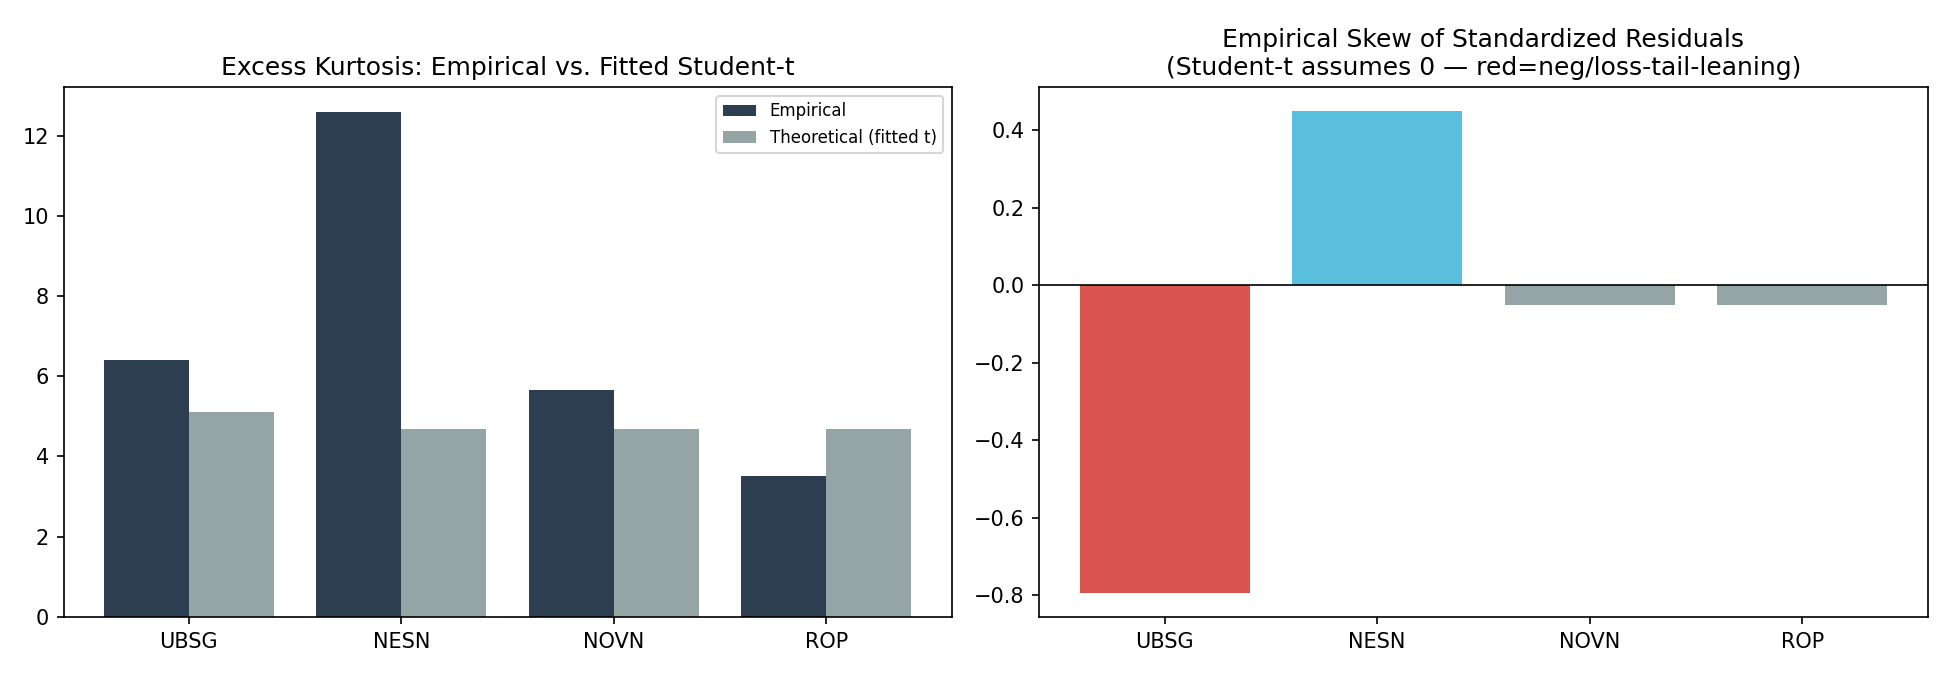

In [12]:
fig_path = plot_tail_diagnostic(tail_diag, 'm2_03_tail_diagnostic.png')
show(fig_path)


Left panel: NESN's bar is visibly the tallest gap between empirical
and theoretical kurtosis — the "worst mismatch" by that metric alone, which
is exactly why kurtosis alone would have been a misleading way to pick the
mechanism. Right panel: UBSG is the only name with a clearly negative
(loss-tail-leaning) skew bar, which is the piece that actually lines up with
which name failed the backtest.

## 8. 10-day stress VaR: Monte Carlo vs. Filtered Historical Simulation

Per architecture: Monte Carlo forward simulation (model-consistent, Student-t
innovations) as primary, FHS (bootstrap-resampled empirical standardized
residuals) as cross-check — reported side by side, not blended.

In [13]:
from stress_var import compare_mc_fhs
from garch_models import fit_series_vt, fit_pooled_vt

ubsg_vt_fit = fit_series_vt(returns['UBSG'], n_random=6)
eps_ubsg = (returns['UBSG'] - returns['UBSG'].mean()).values
print('UBSG: MC vs FHS, 10-day VaR')
print(compare_mc_fhs(eps_ubsg, ubsg_vt_fit['params']).to_string(index=False))


UBSG: MC vs FHS, 10-day VaR
level  MC_VaR  FHS_VaR  abs_diff  pct_diff_of_MC
  95% -0.0737  -0.0821    0.0084         11.4090
  99% -0.1224  -0.1367    0.0143         11.6749


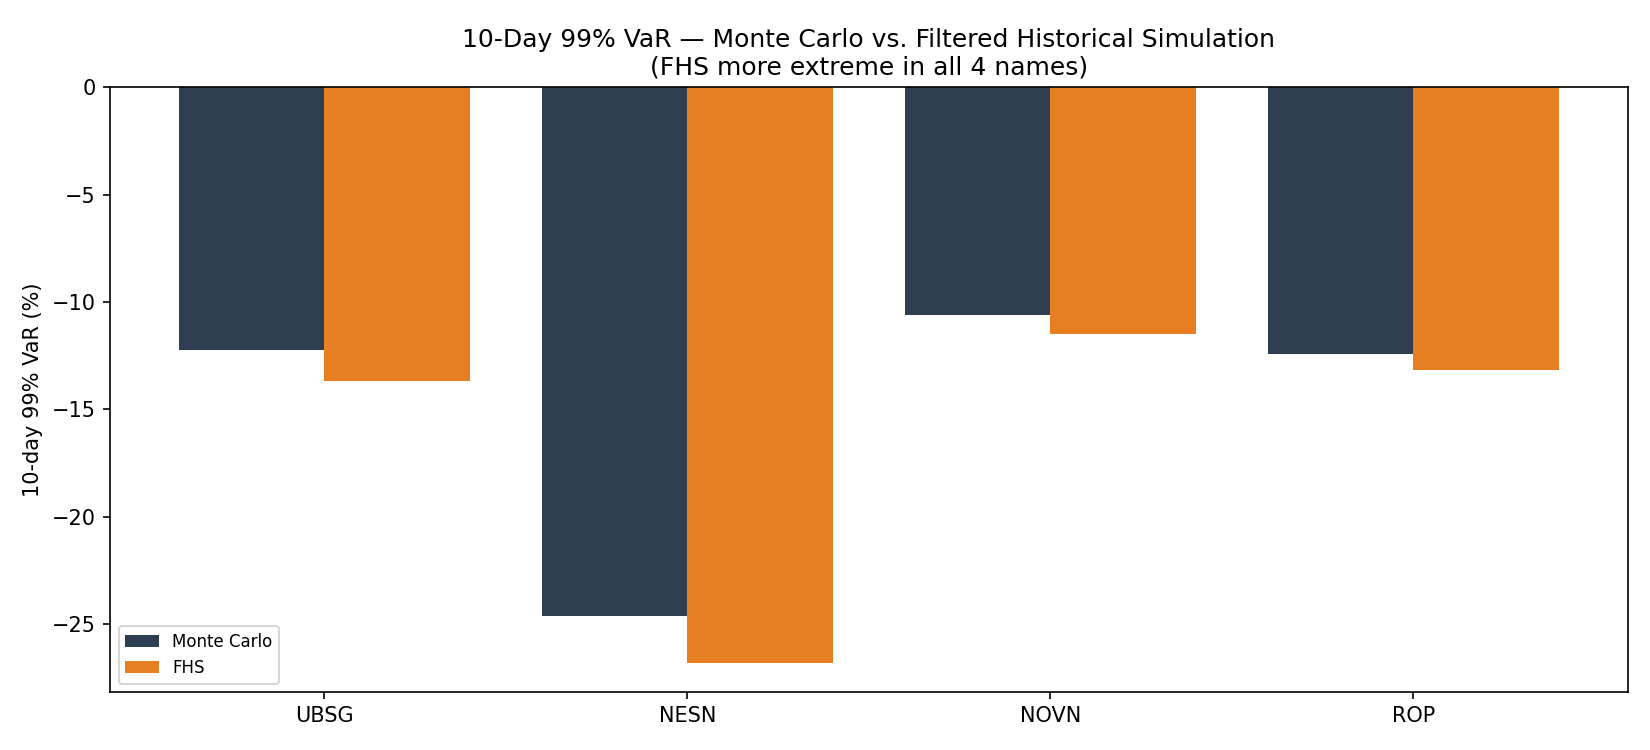

In [14]:
# Full comparison across all four names, for the chart below
pooled_vt_fit = fit_pooled_vt({k: returns[k] for k in ['NESN','NOVN','ROP']}, n_random=6)
shared = pooled_vt_fit['shared']

compare_dfs = {'UBSG': compare_mc_fhs(eps_ubsg, ubsg_vt_fit['params'])}
for name in ['NESN','NOVN','ROP']:
    params = {**shared, 'omega': pooled_vt_fit['omega_by_series'][name]}
    eps_name = (returns[name] - returns[name].mean()).values
    compare_dfs[name] = compare_mc_fhs(eps_name, params)

fig_path = plot_mc_vs_fhs(compare_dfs, 'm2_04_mc_vs_fhs.png')
show(fig_path)


**FHS is more extreme than MC in all 8 name×level comparisons (8/8),
by 5.9%-11.7%.** Too consistent to report as unexplained model uncertainty.
Traced to the same mechanism as Section 7: the fitted Student-t assumption
is measurably too thin-tailed relative to the empirical residuals (confirmed
via direct excess-kurtosis and quantile comparison, Section 7 table).
**Working recommendation: FHS as the primary 10-day stress number for Risk
reporting; MC retained as the model-diagnostic cross-check**, since the gap
between them is itself informative about model specification, not noise to
average away.

## Business Insights

1. **The separate-vs-pooled decision for UBSG is well-evidenced, not
   asserted**: a standalone post-merger LR test (p<10⁻⁶) despite a short
   window, combined with a verified (not assumed) conservatism check showing
   separate treatment implies higher volatility and larger VaR for UBSG than
   pooled parameters would. Caveat: 780 post-merger observations is still
   short for a permanent structural-break claim.
2. **UBSG's 99% VaR undercoverage is real, not a fitting artifact, and not
   attributable to persistence or the Credit Suisse crisis window
   specifically** — both were tested and eliminated. What survives is a
   quantified skew/tail-mismatch specific to UBSG among the four names,
   pointing toward asymmetric innovation modeling as the most promising fix.
3. **The 10-day MC/FHS gap and the 1-day skew finding are the same underlying
   issue viewed at two horizons** — the symmetric Student-t assumption
   understates loss-side tail risk in both. This is a single, well-evidenced
   model-specification finding, not two unrelated observations.
4. **Two real fitting bugs were caught this milestone, both by verification
   rather than by trusting a clean-looking output**: a negative LR statistic
   (impossible under nested-model theory) and a systemic omega-boundary
   degeneracy affecting nearly half of the walk-forward refits. Both would
   have silently corrupted the headline numbers if accepted at face value.

## Lessons Learned

- **A result that looks statistically impossible (negative LR statistic) is
  not evidence of a surprising finding — it's evidence of a broken
  computation.** Nested-model theory gave a hard, checkable constraint;
  building that check into the code (not just the analysis) means the failure
  mode can't silently reappear in Milestone 3.
- **Fixing a data or fitting issue and checking whether the finding survives
  in the *unfavorable* direction is a stronger test than checking whether it
  survives at all.** The VT fix could have made UBSG's violation count
  improve (exonerating the model) or worsen (implicating it); checking which
  actually happened, rather than assuming, is what let the fitting-artifact
  hypothesis be genuinely ruled out rather than just not-yet-confirmed.
- **A compelling, dated, named narrative (SVB/Credit Suisse crisis driving
  refit-8's violations) still needs to be checked against the right null
  distribution before being trusted** — a max-over-23-quarters statistic is a
  different, weaker claim than a single-quarter anomaly, and conflating them
  is the same shape of error as the uncorrected multiple-Kupiec-tests issue.
- **A passing formal test (Christoffersen) and an eyeballed pattern (3
  violations in 5 days) are not automatically in conflict** — checking what
  the formal test actually measures (lag-1, globally aggregated) before
  assuming a contradiction avoids either dismissing a real observation or
  overriding a valid test result.
- **Full-sample diagnostics and walk-forward out-of-sample diagnostics can
  give materially different answers on the same question** (the UBSG
  excess-kurtosis gap was ~14 on full-sample residuals, ~1.3 on the
  walk-forward-consistent ones) — always confirm which sample a diagnostic
  actually used before generalizing from it.

## Limitations

- UBSG separate-vs-pooled decision and the skew/tail-mismatch finding both
  rest partly on a ~2-year post-merger / out-of-sample window — treat as
  current best evidence, not permanent conclusions.
- 99% VaR backtest power remains limited (~14 expected violations) even with
  the extended window; the borderline UBSG finding should be revisited as
  more out-of-sample data accumulates.
- Event-clustering was tested with a simple max-of-23 Poisson/Binomial null;
  a more rigorous event-study design (Section 7b) was not built this
  milestone and remains a legitimate follow-up if Risk wants the crisis-window
  question revisited properly rather than closed on this test alone.
- MC/FHS comparison uses a single full-sample fit for the 10-day stress
  illustration in Section 8, not a walk-forward version — consistent with
  Milestone 2 scope (stress test methodology, not a full walk-forward stress
  backtest), but flagged as a scope boundary, not an oversight.

## Next Step (Milestone 3)

Test skewed-t and/or nonparametric innovation distributions for UBSG,
motivated by the quantified, walk-forward-verified skew/tail-mismatch finding
that survived every check run against competing explanations this milestone.
Event-clustering (Section 7b) retained as a lower-priority, not-fully-closed
thread if a proper event-study design becomes worth building. ML challenger
model (LSTM / gradient boosting on realized vol) as previously scoped.
